<a href="https://colab.research.google.com/github/mlcodr/Fraud_Detection/blob/main/notebooks/fraud_detection_mahfuz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
## Standard Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import datetime
print(f"Last Updated: {datetime.datetime.now()}")

Last Updated: 2026-05-12 20:42:25.241538


In [3]:
!pip install opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: joint-gradient
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud


100%|██████████| 66.0M/66.0M [00:04<00:00, 17.3MB/s]


In [4]:
card_data = pd.read_csv("/content/creditcardfraud/creditcard.csv")

In [5]:
card_data.head(2)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0


In [6]:
card_data.tail(2)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.0,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,-0.915427,-1.040458,-0.031513,-0.188093,-0.084316,0.041333,-0.302620,-0.660377,0.167430,-0.256117,0.382948,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.0,0


In [7]:
card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
## Checking the number of missing values in each column
card_data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [9]:
## Distribution of legit transaction and non-legit transaction
card_data['Class'].value_counts()

,count
Class,
0,284315
1,492


In [10]:
## Splitting the data
legit = card_data[card_data.Class == 0]
fraud = card_data[card_data.Class == 1]
legit.shape , fraud.shape

 ### This shows the number of fraud and legit data over the dataset

((284315, 31), (492, 31))

In [11]:
card_data.Amount.describe()

,Amount
count,284807.000000
mean,88.349619
std,250.120109
min,0.000000
25%,5.600000
50%,22.000000
75%,77.165000
max,25691.160000


In [12]:
legit.Amount.describe()

,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


In [13]:
fraud.Amount.describe()

,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


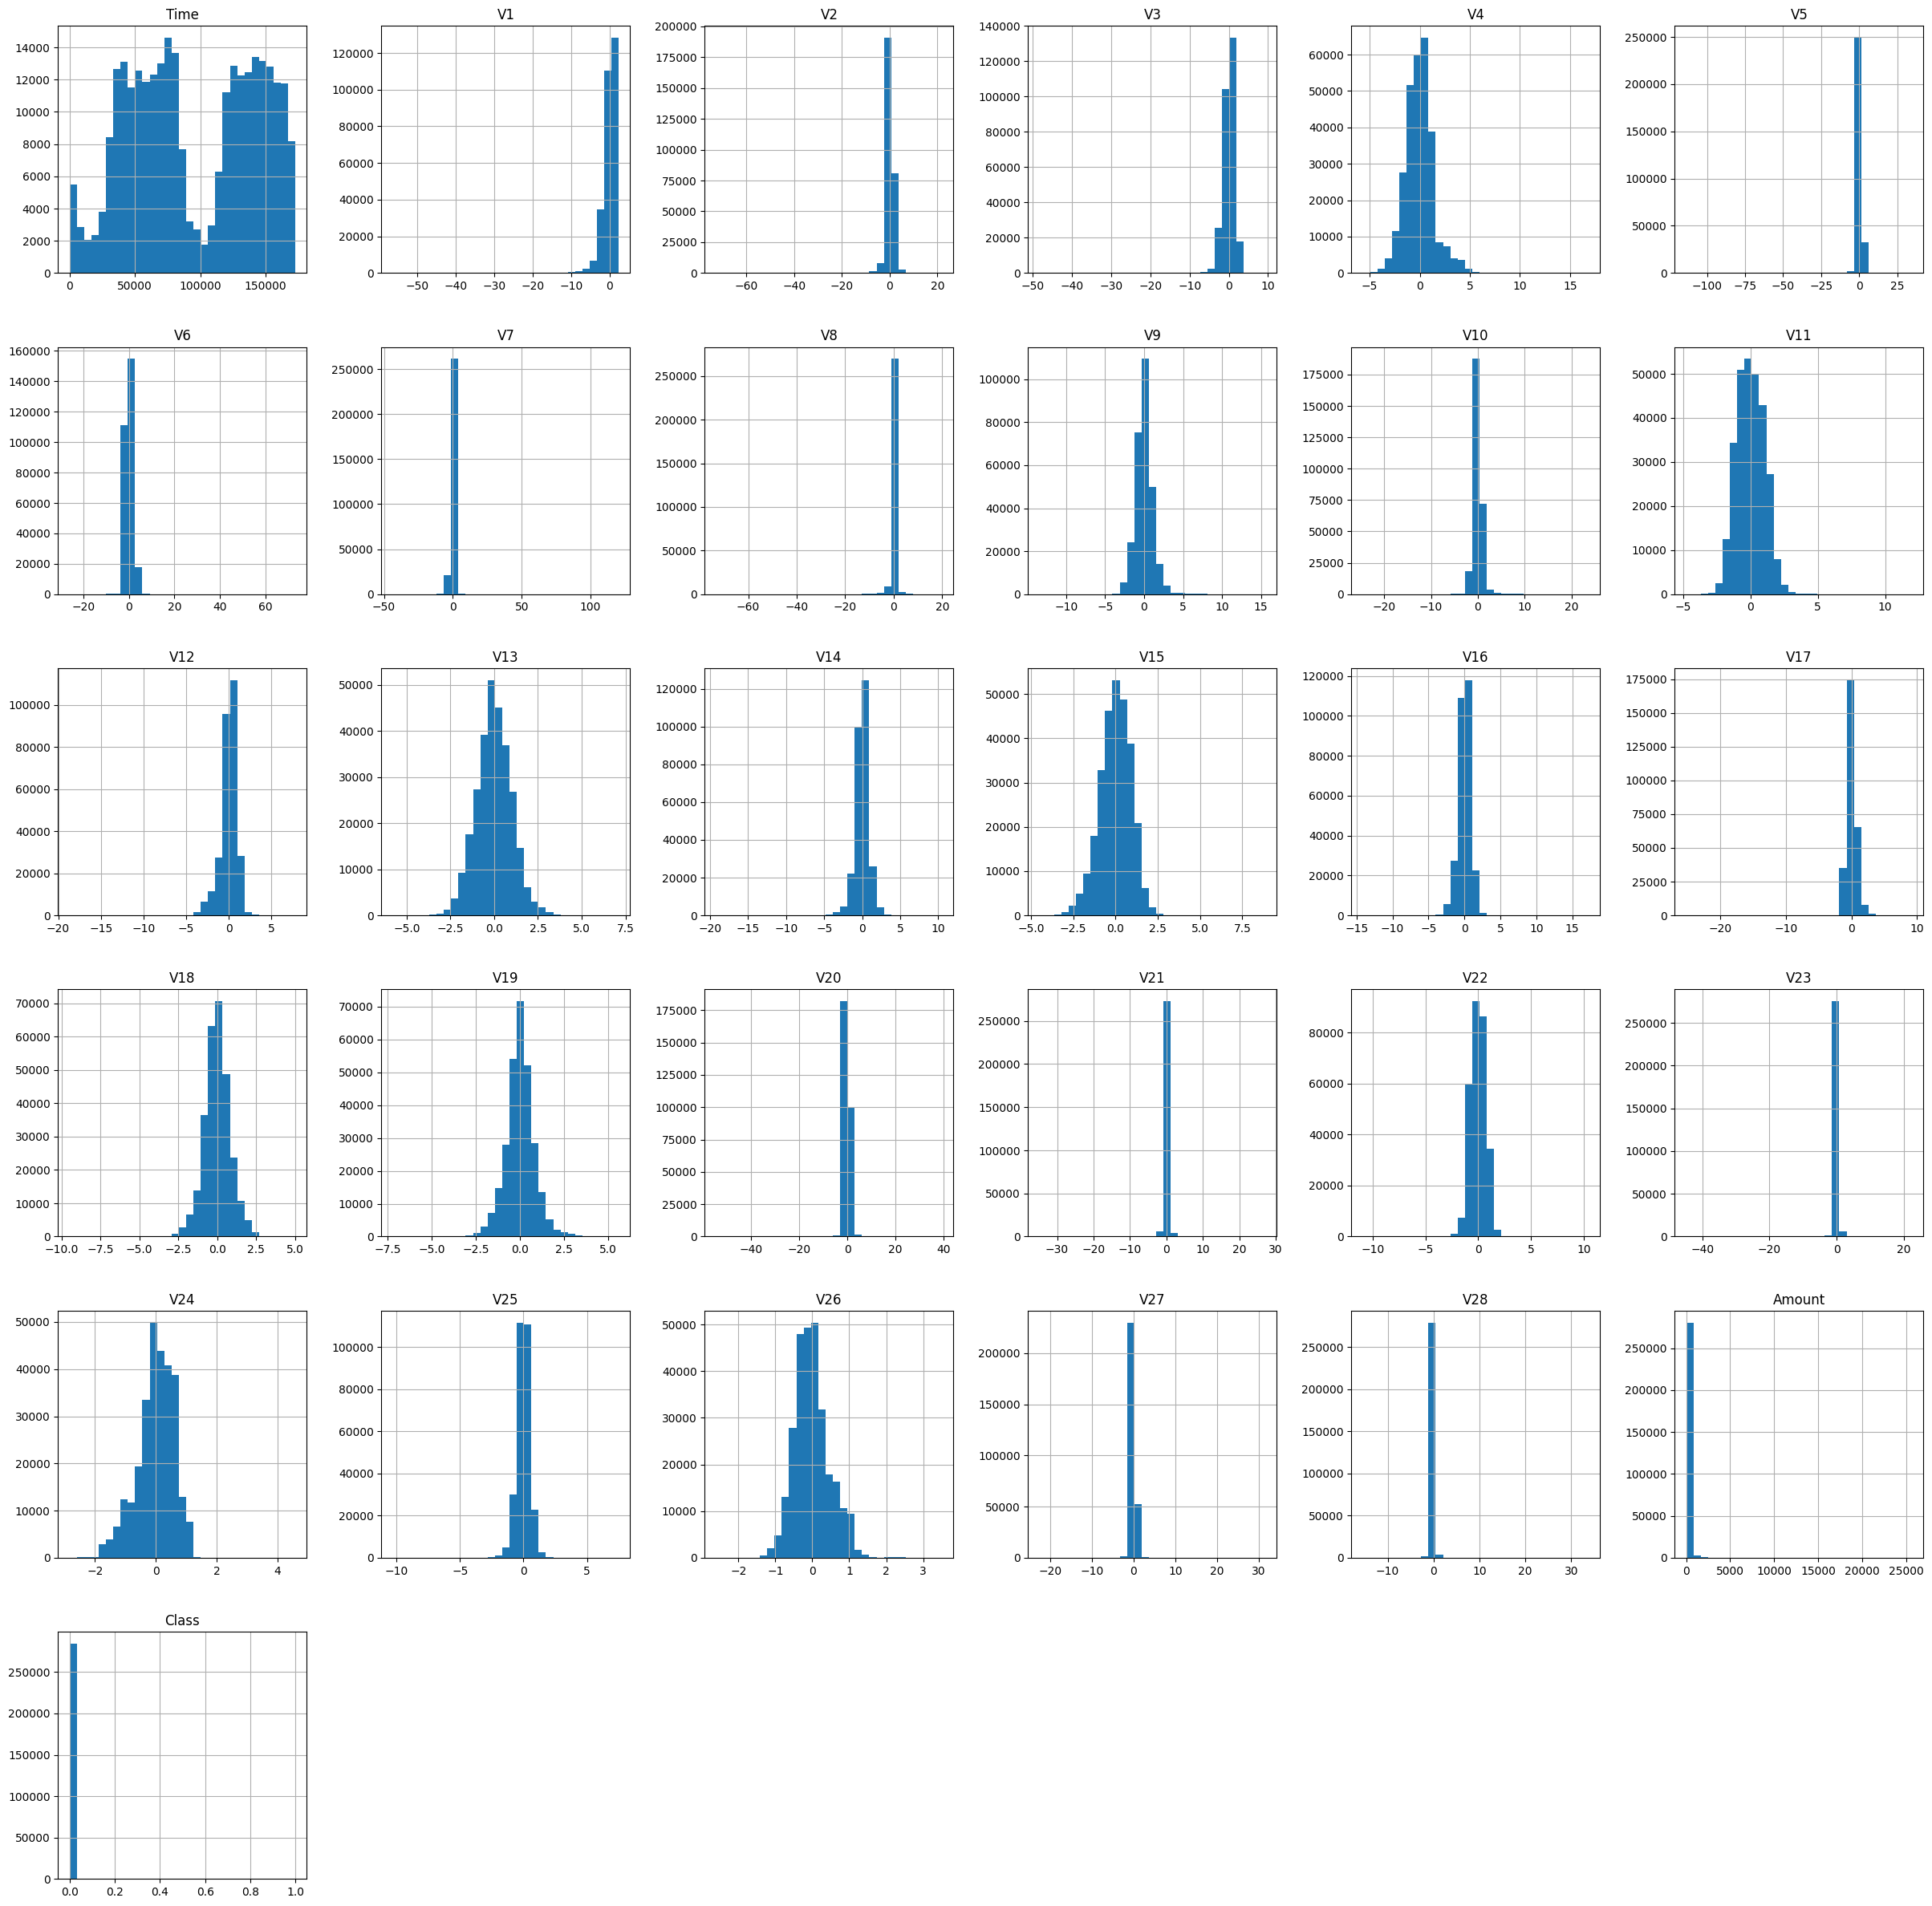

In [14]:
## Visualization of Each Column
card_data.hist(bins = 31, figsize = (30,30));

In [15]:
card_data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


#### **Data Preprocessing**

In [16]:
## Because all the PCA data is almost decimal but the amount raw currency which will confuse the model
from sklearn.preprocessing import RobustScaler
new_card_data = card_data.copy()
new_card_data["Amount"] = RobustScaler().fit_transform(new_card_data["Amount"].to_numpy().reshape(-1,1))

In [17]:
pd.DataFrame(new_card_data["Amount"])

,Amount
0,1.783274
1,-0.269825
2,4.983721
3,1.418291
4,0.670579
...,...
284802,-0.296653
284803,0.038986
284804,0.641096
284805,-0.167680


In [18]:
new_card_data["Amount"].describe()

,Amount
count,284807.000000
mean,0.927124
std,3.495006
min,-0.307413
25%,-0.229162
50%,0.000000
75%,0.770838
max,358.683155


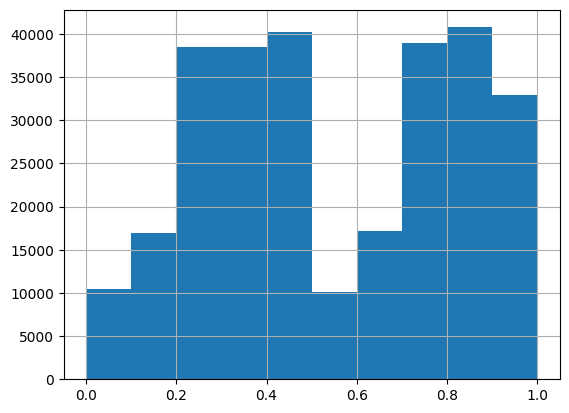

In [19]:
## Now we have to downscale the time column
time = new_card_data["Time"]
new_card_data['Time'] = (time - time.min()) / (time.max() - time.min())
new_card_data["Time"].hist();

In [20]:
new_card_data.Time.describe()

,Time
count,284807.000000
mean,0.548717
std,0.274828
min,0.000000
25%,0.313681
50%,0.490138
75%,0.806290
max,1.000000


In [21]:
pd.DataFrame(new_card_data["Time"])

,Time
0,0.000000
1,0.000000
2,0.000006
3,0.000006
4,0.000012
...,...
284802,0.999965
284803,0.999971
284804,0.999977
284805,0.999977


In [22]:
## Splitting the data to train , test and validation
train,test,val = new_card_data[:240000], new_card_data[240000:260000], new_card_data[260000:]
train["Class"].value_counts(),test["Class"].value_counts(),val["Class"].value_counts()

(Class
 0    239563
 1       437
 Name: count, dtype: int64,
 Class
 0    19966
 1       34
 Name: count, dtype: int64,
 Class
 0    24786
 1       21
 Name: count, dtype: int64)

In [23]:
train_np, test_np, val_np = train.to_numpy(),test.to_numpy(),val.to_numpy()
train_np.shape,test_np.shape,val_np.shape

((240000, 31), (20000, 31), (24807, 31))

In [24]:
x_train , y_train = train_np[ : , : -1 ], train_np[ : , -1]
x_test , y_test = test_np[ : , : -1 ], test_np[ : , -1]
x_val , y_val = val_np[ : , : -1 ], val_np[ : , -1]

In [25]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression()
logistic_model.fit(x_train,y_train)
print(f"Accuracy on training set: {logistic_model.score(x_train,y_train)*100:.2f}%")
print(f"Accuracy on testing set: {logistic_model.score(x_test,y_test)*100:.2f}%")

Accuracy on training set: 99.91%
Accuracy on testing set: 99.92%


In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_val,logistic_model.predict(x_val),target_names = ["Legit" , "Fraud"]))

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     24786
       Fraud       0.83      0.24      0.37        21

    accuracy                           1.00     24807
   macro avg       0.92      0.62      0.69     24807
weighted avg       1.00      1.00      1.00     24807



Our Model is lying to us because of this imbalanced dataset.

---
We need to understand Four Quadrants


*   True Positive (TP) : The transaction was Fraud, and the model flagged it as Fraud.
*   True Negative (TN) : The transaction was legit, and the model flagged it as legit
*   False Positive (FP) : The transaction was legit, and the model flagged it as fraud
*   False Negative (FN) : The transaction was fraud, and the model flagged it as legit
---



*   Here Accuracy Score 1.00 (99.9%) is useless because It's high only because most transactions are "Legit."
*   Precision is When it flags fraud, it's right 83% of the time. Pretty good!
*   Recall is Bad. It's only catching 24% of the actual fraud. 76% is getting away.
*  F1-Score is low. Because the recall is so bad, the overall "balance" is poor , it's just the mean value of precision and recall.












In [27]:
!pip install tensorflow
import tensorflow as tf

In [28]:
## Creating a Shallow Neural Network
## Making a shallow neural network
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import backend as K

K.clear_session()

shallow_nn = Sequential()
shallow_nn.add(InputLayer((x_train.shape[1],)))
shallow_nn.add(Dense(units = 2, activation = "relu"))
shallow_nn.add(BatchNormalization())
shallow_nn.add(Dense(units = 1,activation = "sigmoid"))
checkpoints = ModelCheckpoint("shallow_nn.keras",save_best_only=True)
shallow_nn.compile(optimizer="adam", loss = "binary_crossentropy",metrics = ["accuracy"])

In [29]:
shallow_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │            62 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2)              │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73 (292.00 B)

 Trainable params: 69 (276.00 B)

 Non-trainable params: 4 (16.00 B)

In [30]:
shallow_nn.fit(x_train,y_train,validation_data=(x_val,y_val),epochs = 5, verbose = 1, callbacks= checkpoints);

Epoch 1/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - accuracy: 0.9836 - loss: 0.0509 - val_accuracy: 0.9996 - val_loss: 0.0027
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9992 - loss: 0.0037 - val_accuracy: 0.9996 - val_loss: 0.0028
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9992 - loss: 0.0036 - val_accuracy: 0.9996 - val_loss: 0.0025
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9993 - loss: 0.0034 - val_accuracy: 0.9992 - val_loss: 0.0032
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9992 - loss: 0.0034 - val_accuracy: 0.9995 - val_loss: 0.0027


In [31]:
## Creating a function that will predict from neural networks
def neural_net_predictions(model,x):
  return  (shallow_nn.predict(x).flatten() > 0.5).astype(int)
neural_net_predictions(shallow_nn,x_val)

776/776 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([0, 0, 0, ..., 0, 0, 0])

In [32]:
## Checkng out the Classification Report
print(f"Classification Report:\n{classification_report(y_val, neural_net_predictions(shallow_nn, x_val), target_names=['Legit', 'Fraudulent'])}")

776/776 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     24786
  Fraudulent       0.71      0.71      0.71        21

    accuracy                           1.00     24807
   macro avg       0.86      0.86      0.86     24807
weighted avg       1.00      1.00      1.00     24807



In [36]:
## Trying with Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(max_depth = 2, n_jobs = -1)
random_forest.fit(x_train,y_train)
print(f"Classification Report:\n{classification_report(y_val, random_forest.predict(x_val), target_names=['Not Fraud', 'Fraud'])}")

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     24786
       Fraud       0.89      0.38      0.53        21

    accuracy                           1.00     24807
   macro avg       0.94      0.69      0.77     24807
weighted avg       1.00      1.00      1.00     24807



In [39]:
## Let's try with Gradient Boosting Model
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier(n_estimators = 50, learning_rate = 0.5, max_depth = 1, random_state = 1)
gbc.fit(x_train,y_train)
print(f"Classification Report:\n{classification_report(y_val, gbc.predict(x_val), target_names=['Not Fraud', 'Fraud'])}")

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     24786
       Fraud       0.75      0.57      0.65        21

    accuracy                           1.00     24807
   macro avg       0.87      0.79      0.82     24807
weighted avg       1.00      1.00      1.00     24807



In [41]:
## Let's try with SVC (Support Vector Classifier)
from sklearn.svm import LinearSVC
svc = LinearSVC(class_weight = "balanced")
svc.fit(x_train,y_train)
print(f"Classification Report:\n{classification_report(y_val, svc.predict(x_val), target_names=['Not Fraud', 'Fraud'])}")

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      0.99     24786
       Fraud       0.06      0.76      0.10        21

    accuracy                           0.99     24807
   macro avg       0.53      0.88      0.55     24807
weighted avg       1.00      0.99      0.99     24807

